# 07. Подбор гиперпараметров, интерпретация и сохранение модели

Ноутбук закрывает пункты ТЗ: подбор гиперпараметров для лучшей модели, feature importance, объяснение решений и сохранение итоговой модели.

In [1]:
from pathlib import Path
import re

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymorphy3

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

## Загрузка данных

In [2]:
DATA_PATH = Path("../data_with_efficientnet_features.csv")
df = pd.read_csv(DATA_PATH)

effnet_cols = [col for col in df.columns if col.startswith("effnet_feat_")]
assert effnet_cols, "В датасете не найдены колонки effnet_feat_*"

print(f"Rows: {len(df)}")
print(f"EfficientNet features: {len(effnet_cols)}")

Rows: 327
EfficientNet features: 1280


## Общие функции

In [3]:
RANDOM_STATE = 42
VOWELS = set("аеёиоуыэюя")
RARE_LETTERS = set("фщъёцэ")
morph = pymorphy3.MorphAnalyzer()


def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def clean_and_lemmatize(text):
    if pd.isna(text):
        return "пусто"
    words = re.findall(r"[а-яёa-z]+", str(text).lower())
    if not words:
        return "пусто"
    return " ".join(morph.parse(word)[0].normal_form for word in words)


def extract_rebus_logic(row):
    desc = str(row["description"]).lower()
    ans = str(row["answer"]).lower().split("|")[0]
    pos_prepositions = [" в ", " на ", " под ", " над ", " за ", " перед ", " из "]
    rebus_terms = ["запятая", "перевернутый", "вверх ногами", "зачеркнуть", "буква", "цифра"]

    return pd.Series(
        {
            "comma_count": desc.count(",") + desc.count("'"),
            "desc_len": len(desc),
            "ans_len": len(ans.replace(" ", "")),
            "has_pos_prep": int(any(prep in desc for prep in pos_prepositions)),
            "has_rebus_terms": int(any(term in desc for term in rebus_terms)),
            "is_multi_word_ans": int(" " in ans.strip()),
            "variant_count": str(row["answer"]).count("|") + 1,
        }
    )


def evaluate_model(model, X, y):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": make_scorer(rmse_score, greater_is_better=False),
    }
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    return {
        "r2_mean": scores["test_r2"].mean(),
        "mae_mean": -scores["test_mae"].mean(),
        "rmse_mean": -scores["test_rmse"].mean(),
    }


## Финальный набор признаков

По предыдущему сравнению лучшим текстовым подходом является NLP-подход. Здесь он объединяется с EfficientNet-признаками, а гиперпараметры подбираются для финального pipeline.

In [4]:
nlp_df = df.copy()
nlp_df["lemma_description"] = nlp_df["description"].apply(clean_and_lemmatize)
nlp_df["lemma_answer"] = nlp_df["answer"].apply(lambda value: clean_and_lemmatize(str(value).split("|")[0]))
rebus_features = nlp_df.apply(extract_rebus_logic, axis=1)

X = pd.concat([nlp_df[["lemma_description", "lemma_answer"]], rebus_features, df[effnet_cols]], axis=1)
y = df["difficulty"].copy()

nlp_numeric_cols = rebus_features.columns.tolist()
N_EFFNET_COMPONENTS = min(50, len(df) - 1, len(effnet_cols))

preprocessor = ColumnTransformer(
    [
        ("desc_tfidf", TfidfVectorizer(max_features=500), "lemma_description"),
        ("ans_tfidf", TfidfVectorizer(analyzer="char", ngram_range=(2, 4), max_features=300), "lemma_answer"),
        ("num", StandardScaler(), nlp_numeric_cols),
        (
            "effnet",
            Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=N_EFFNET_COMPONENTS, random_state=RANDOM_STATE))]),
            effnet_cols,
        ),
    ]
)

base_pipeline = Pipeline([("preprocessor", preprocessor), ("model", Ridge())])
X.shape

(327, 1289)

## Подбор гиперпараметров

In [5]:
param_grid = {
    "preprocessor__desc_tfidf__max_features": [150, 300, 500, 800],
    "preprocessor__ans_tfidf__max_features": [200, 300, 500, 750, 1000, 2000],
    "preprocessor__effnet__pca__n_components": [15, 30, 50],
    "model__alpha": [0.1, 0.5, 1.0, 10.0, 30.0],
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rmse_scorer = make_scorer(rmse_score, greater_is_better=False)

grid = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

grid.fit(X, y)

print(f"Best CV MAE: {-grid.best_score_:.6f}")
grid.best_params_

Best CV MAE: 0.077713


{'model__alpha': 0.5,
 'preprocessor__ans_tfidf__max_features': 2000,
 'preprocessor__desc_tfidf__max_features': 500,
 'preprocessor__effnet__pca__n_components': 30}

## Сравнение модели до и после tuning

In [6]:
default_metrics = evaluate_model(base_pipeline, X, y)
tuned_metrics = evaluate_model(grid.best_estimator_, X, y)

comparison = pd.DataFrame(
    [
        {"model": "default_ridge", **default_metrics},
        {"model": "tuned_ridge", **tuned_metrics},
    ]
).sort_values("mae_mean")
comparison

,model,r2_mean,mae_mean,rmse_mean
1,tuned_ridge,0.136747,0.077713,0.097261
0,default_ridge,0.054502,0.081644,0.101901


## Holdout и анализ ошибок

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
final_model = clone(grid.best_estimator_)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

holdout_metrics = pd.DataFrame(
    [
        {
            "model": "tuned_ridge",
            "mae": mean_absolute_error(y_test, y_pred),
            "rmse": rmse_score(y_test, y_pred),
            "r2": r2_score(y_test, y_pred),
        }
    ]
)
holdout_metrics

,model,mae,rmse,r2
0,tuned_ridge,0.075009,0.097075,0.030874


In [8]:
errors = pd.DataFrame(
    {
        "answer": df.loc[y_test.index, "answer"],
        "description": df.loc[y_test.index, "description"],
        "actual_difficulty": y_test,
        "predicted_difficulty": y_pred,
        "absolute_error": np.abs(y_test - y_pred),
    }
).sort_values("absolute_error", ascending=False)

errors.head(20)

,answer,description,actual_difficulty,predicted_difficulty,absolute_error
153,лор|оториноларинголог|отоларинголог|ухогорлонос,Ухо + Горло + Нос,0.0377,0.286308,0.248608
7,рампа,Рамка в виде буквы П. Игра букв,0.3712,0.153144,0.218056
16,сантехника,Sun = Сан + техника (стиральная машина),0.4230,0.212346,0.210654
322,даль,Дал (действие) + Ь,0.4194,0.222050,0.197350
306,учебник,Учеб + Ник (имя персонажа),0.0946,0.275895,0.181295
311,тип,Т + ИП,0.0414,0.217918,0.176518
90,парад,Пара (две) + Д,0.2916,0.130639,0.160961
291,подошва,Под (расположение) + О (буква на обуви) + Шва,0.0424,0.197361,0.154961
309,прошлое,Прошло (форма прошедшего времени) + Е,0.4189,0.264649,0.154251
177,триумф,Три (количество) + Умф,0.0273,0.172575,0.145275


## Интерпретация: permutation importance

In [9]:
importance = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
)

feature_importance = pd.DataFrame(
    {
        "feature": X.columns,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    }
).sort_values("importance_mean", ascending=False)

feature_importance.head(30)

,feature,importance_mean,importance_std
0,lemma_description,0.010212,0.002523
3,desc_len,0.009040,0.005195
1,lemma_answer,0.003565,0.001930
2,comma_count,0.003420,0.001357
4,ans_len,0.002654,0.002721
7,is_multi_word_ans,0.001288,0.000477
5,has_pos_prep,0.000414,0.000794
8,variant_count,0.000281,0.000951
1089,effnet_feat_1080,0.000163,0.000069
821,effnet_feat_812,0.000153,0.000086


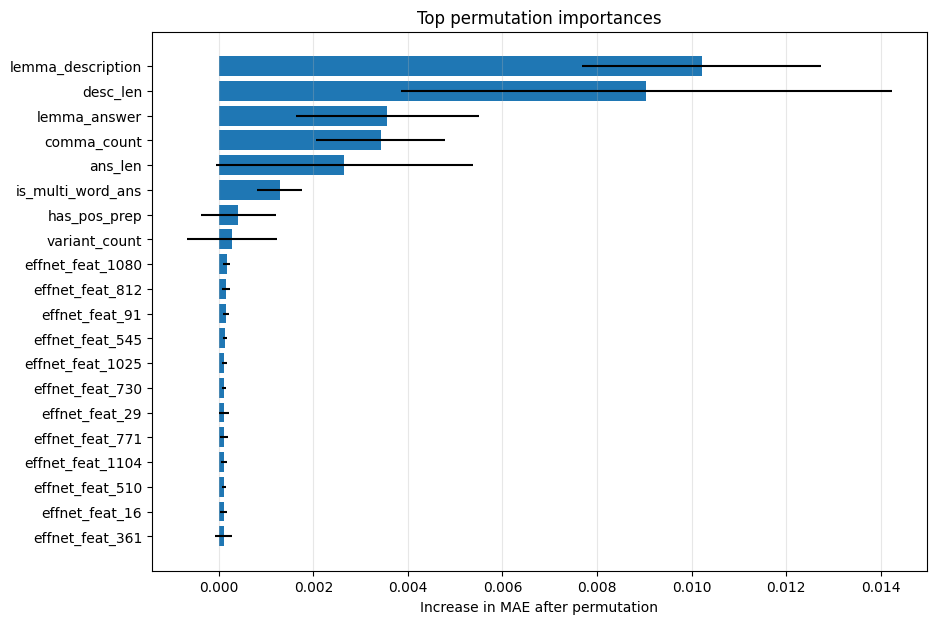

In [10]:
top_features = feature_importance.head(20).sort_values("importance_mean")

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance_mean"], xerr=top_features["importance_std"])
plt.title("Top permutation importances")
plt.xlabel("Increase in MAE after permutation")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

## Объяснение решений модели

Для линейной Ridge-модели итоговый прогноз формируется как взвешенная сумма преобразованных текстовых, числовых и визуальных признаков. На уровне исходных колонок вклад оценивается через permutation importance: если перемешивание признака повышает MAE, значит модель действительно использует этот признак.

In [11]:
explanation_summary = pd.DataFrame(
    [
        ("Высокая permutation importance", "признак заметно влияет на ошибку и полезен для прогноза"),
        ("Нулевая или отрицательная importance", "признак не дает устойчивого улучшения на holdout"),
        ("Большие ошибки в errors", "объекты, где текущих признаков недостаточно для объяснения сложности"),
    ],
    columns=["observation", "interpretation"],
)
explanation_summary

,observation,interpretation
0,Высокая permutation importance,признак заметно влияет на ошибку и полезен для...
1,Нулевая или отрицательная importance,признак не дает устойчивого улучшения на holdout
2,Большие ошибки в errors,"объекты, где текущих признаков недостаточно дл..."


## Сохранение модели

In [12]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

final_model_full = clone(grid.best_estimator_)
final_model_full.fit(X, y)

model_path = MODEL_DIR / "best_text_efficientnet_model.joblib"
metadata_path = MODEL_DIR / "best_text_efficientnet_model_metadata.csv"

joblib.dump(final_model_full, model_path)

model_metadata = pd.DataFrame(
    [
        {
            "model_path": str(model_path),
            "data_path": str(DATA_PATH),
            "rows": len(df),
            "features": X.shape[1],
            "best_cv_mae": -grid.best_score_,
            "best_params": grid.best_params_,
        }
    ]
)
model_metadata.to_csv(metadata_path, index=False)

model_metadata

,model_path,data_path,rows,features,best_cv_mae,best_params
0,../models/best_text_efficientnet_model.joblib,../data_with_efficientnet_features.csv,327,1289,0.077713,"{'model__alpha': 0.5, 'preprocessor__ans_tfidf..."
